In [1]:
import sys
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

import threading
from concurrent.futures import ThreadPoolExecutor

import magcal

In [2]:
def thread_func(p0, p1, mgz, xobs, yobs, zobs, xgrd, ygrd, zgrd, dim, L):
    '''
    3次元磁気インバージョンの伝達行列を計算
    入力データ数=N, グリッドの総数=M として
    N x M の行列を作成

    [入力]
    xobs, yobs, zobs: 観測点位置(それぞれN次元ベクトル)
    xgrd, ygrd, zgrd: グリッドの中心位置(それぞれM次元ベクトル)
    dim: 各グリッドのディメンジョン

    [出力]
    K: 伝達行列(N x M)
    '''
    m = len(xgrd)
    K = []

    for iz in range(int(p0), int(p1)):
        for iy in range(ny):
            for ix in range(nx):
                
                # j番目のセル
                j = ix + iy*nx + iz*nx*ny
                
                # dim
                dim0_0 = dim[0][0]
                dim0_1 = dim[0][1]
                dim1_0 = dim[1][0]
                dim1_1 = dim[1][1]
                dim2_0 = dim[2][0]
                dim2_1 = dim[2][1]      

                # 端は引き延ばす
                if abs(ix - 0) < 1.e-10:
                    dim0_0 += L
                elif abs(ix - nx + 1) < 1.e-10:
                    dim0_1 += L

                if abs(iy - 0) < 1.e-10:
                    dim1_0 += L
                elif abs(iy - ny + 1) < 1.e-10:
                    dim1_1 += L
                
                dim_new = [[dim0_0, dim0_1], [dim1_0, dim1_1], [dim2_0, dim2_1]] 
                
                c = magcal.prism(mgz, xobs, yobs, zobs, xgrd[j], ygrd[j], zgrd[j], dim_new)
                f = magcal.total_force(mgz, c).reshape(-1, 1)
                del c
                
                if len(K) == 0:
                    K = f.copy()
                else:
                    K = np.hstack((K, f))
                del f
                
                if j%1000 == 0:
                    print(j)

    return K

### Parallel Inversion
L1-L2 penalty

$$
P(\boldsymbol{\beta}) =  \lambda_1 \left\| \boldsymbol{\beta} \right\|_1 + \frac{\lambda_2}{2} \| \boldsymbol{\beta} \|_2^2
$$

In [3]:
# ソフト閾値関数S
def soft_thresholding(x, y):
    return np.sign(x) * np.maximum(np.abs(x) - y, 0.)

# L1-L2 inversion
class L1L2:
    
    # コンストラクタ
    def __init__(self, l_1, l_2, rho_, eta_, min_ = -np.inf, max_ = +np.inf, fit_intercept = False, eps_ADMM = 1.e-5, max_iter=100000):
        
        self.l_1 = l_1
        self.l_2 = l_2       
        self.rho_ = rho_
        self.eta_ = eta_
        self.min_ = min_
        self.max_ = max_
        self.fit_intercept = fit_intercept
        self.eps_ADMM = eps_ADMM
        self.max_iter = max_iter
        
        self.beta_ = None
        self.beta_before = None
        self.b = None
        self.z_ = None
        self.z_before = None
        self.y_ = None
        self.y_before = None
        self.v_ = None
        self.v_before = None
        self.u_ = None
        self.u_before = None

    # アルゴリズム
    def algorithm(self, X, f, w):

        if self.fit_intercept == False:

            # βベクトルの作成
            n, m = X.shape
        
            # 初期化
            self.beta_ = np.dot(X.T, f)
            self.z_ = np.zeros(m)
            self.u_ = np.copy(self.z_) 
            self.v_ = np.copy(self.z_) 
            self.y_ = np.copy(self.z_)
        
            if self.eta_ == 0: # no constrained
                print("No-constrained")
                
                Inv = np.linalg.inv(np.eye(n) + X.dot(X.T) / self.rho_)
                
                # for loop
                for _ in range(self.max_iter):

                    # step1. βの更新
                    self.beta_before = self.beta_.copy()
                    C = np.dot(X.T, f) + self.rho_ * (self.z_ + self.v_)
                    self.beta_ = C / self.rho_ - np.dot(X.T, np.dot(Inv, np.dot(X, C))) / (self.rho_**2)

                    # step2. zの更新
                    self.z_before = self.z_.copy()
                    self.z_ = soft_thresholding(self.rho_ * (self.beta_ - self.v_), self.l_1) / (self.l_2 + self.rho_)

                    # 3. vの更新
                    self.v_ += self.rho_ * (self.z_ - self.beta_)

                    # 終了条件
                    dr = self.z_ - self.beta_
                    ds = self.rho_ * (self.z_ - self.z_before)

                    delta_r = np.sqrt(np.linalg.norm(dr, ord=2) ** 2 / m)
                    delta_s = np.sqrt(np.linalg.norm(ds, ord=2) ** 2 / m)
                    delta = max(delta_r, delta_s)

                    if _ % 1000 == 0:
                        print("iter = {}, delta = {}".format(_, delta))

                    if delta <= self.eps_ADMM:
                        print(_)
                        break               
                
                
            if self.eta_ != 0: # constraind
                print("Constrained")
            
                Inv = np.linalg.inv(np.eye(n) + X.dot(X.T) / (self.rho_ + self.eta_))
        
                # for loop
                for _ in range(self.max_iter):

                    # step1. βの更新
                    self.beta_before = self.beta_.copy()
                    C = np.dot(X.T, f) + self.rho_ * (self.z_ + self.v_) + self.eta_ * (self.y_ + self.u_)
                    self.beta_ = C / (self.rho_ + self.eta_) - np.dot(X.T, np.dot(Inv, np.dot(X, C))) / (self.rho_ + self.eta_) / (self.rho_ + self.eta_)

                    # step2. zの更新
                    self.z_before = self.z_.copy()
                    self.z_ = soft_thresholding(self.rho_ * (self.beta_ - self.v_), self.l_1) / (self.l_2 + self.rho_)

                    # step3. yの更新
                    self.y_before = self.y_.copy()
                    self.y_ = np.maximum(self.beta_ - self.u_, self.min_)

                    # step4. vの更新
                    self.v_ += self.rho_ * (self.z_ - self.beta_)

                    # step5. uの更新
                    self.u_ += self.eta_ * (self.y_ - self.beta_)

                    # 終了条件
                    dr = self.z_ - self.beta_
                    ds = self.rho_ * (self.z_ - self.z_before)

                    delta_r = np.sqrt(np.linalg.norm(dr, ord=2) ** 2 / m)
                    delta_s = np.sqrt(np.linalg.norm(ds, ord=2) ** 2 / m)
                    delta = max(delta_r, delta_s)

                    dr_BC = self.y_ - self.beta_
                    ds_BC = self.eta_ * (self.y_ - self.y_before)

                    delta_r_BC = np.sqrt(np.linalg.norm(dr_BC, ord=2) ** 2 / m)
                    delta_s_BC = np.sqrt(np.linalg.norm(ds_BC, ord=2) ** 2 / m)

                    delta_BC = max(delta_r_BC, delta_s_BC)

                    if _ % 1000 == 0:
                        print("delta = {}, delta_BC = {}".format(delta, delta_BC))

                    if (max(delta, delta_BC) <= self.eps_ADMM):
                        print(_)
                        break

In [4]:
# data misfit
def misfit(f, K, beta_star):
    return 0.5 * np.linalg.norm(f - K.dot(beta_star))**2

# penalty
def pen(beta, alpha):
    pen_1 = np.linalg.norm(beta, 1)
    pen_2 = 0.5 * np.linalg.norm(beta, 2)**2
    pen_all = alpha * pen_1 + (1. - alpha) * pen_2
    return pen_all

In [5]:
def calcCurvature2(x,y):
    
    dif_x = np.gradient(x)
    dif_y = np.gradient(y)
    dif2_x = np.gradient(dif_x)
    dif2_y = np.gradient(dif_y)
    
    curvature = np.abs(dif2_x * dif_y - dif_x * dif2_y) / (dif_x **2 + dif_y **2)**1.5
    return curvature

### 空間領域

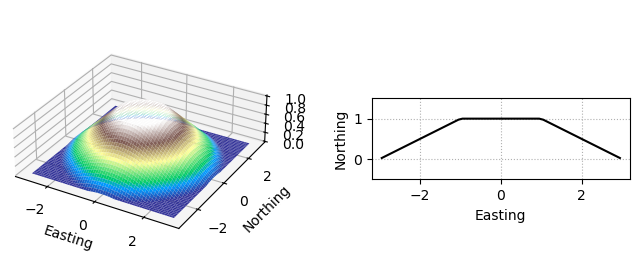

In [6]:
### 地下グリッドの作成: xgrd, ygrd, zgrd ###
# incx, incy, incz : x, y, z方向のグリッド間隔
incx = 0.1
incy = 0.1
incz = 0.1

x = np.arange(-3.0 + 0.5*incx, 3.0, incx)
y = np.arange(-3.0 + 0.5*incy, 3.0, incy)
nx = len(x)
ny = len(y)
X, Y = np.meshgrid(x, y)

# 山型の地形
T = np.zeros(X.shape)
for iy in range(len(y)):
    for ix in range(len(x)):
        r = np.sqrt(X[iy, ix]**2 + Y[iy, ix]**2)
        if r <= 1:
            T[iy, ix] = 1.
        elif (1 <= r) and (r <= 3):
            T[iy, ix] = - 0.5*r + 1.5

### 地下グリッドの作成: xgrd, ygrd, zgrd ###
# 地下の層数 = 30  # 60×60×30
nz = 30
[yy2, zz2, xx2] = np.meshgrid(y, np.zeros(nz), x)

for k in range(nz):
    for i in range(nx):
        for j in range(ny):
            zz2[k, j, i] = T.reshape(-1)[i + nx*j] - incz / 2. - incz*k
            
xgrd = xx2.reshape(-1)
ygrd = yy2.reshape(-1)
zgrd = zz2.reshape(-1)

# 図示用
xfig, yfig, zfig = [], [], []

for i in range(len(xgrd)):
    j = i // (nx*ny)
    
    # 各グリッドの8頂点の座標を格納
    xfig.append([xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, 
                 xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx])
    yfig.append([ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy, 
                 ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy])
    zfig.append([zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, 
                 zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz])

# array化
xfig = np.array(xfig)
yfig = np.array(yfig)
zfig = np.array(zfig)

#dim: ブロックのサイズ
dim = [[incx / 2., incx / 2.], [incy / 2., incy / 2.], [incz / 2., incz / 2.]]

# 東京付近
# 偏角(度)
dec = -7.
# 伏角(度)
inc = 50.

# 図示
fig = plt.figure(figsize = (8, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.)

ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, T, rstride=1, cstride=1, cmap = plt.cm.terrain)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_box_aspect((1,1,0.3))

ax = fig.add_subplot(122)
ys = 29
ax.plot(X[ys, :], T[ys,:], color = "black")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.5, 1.5)
ax.grid(linestyle = "dotted")

### 空中磁気探査（正規グリッド）

CPU times: total: 13.8 s
Wall time: 13.8 s


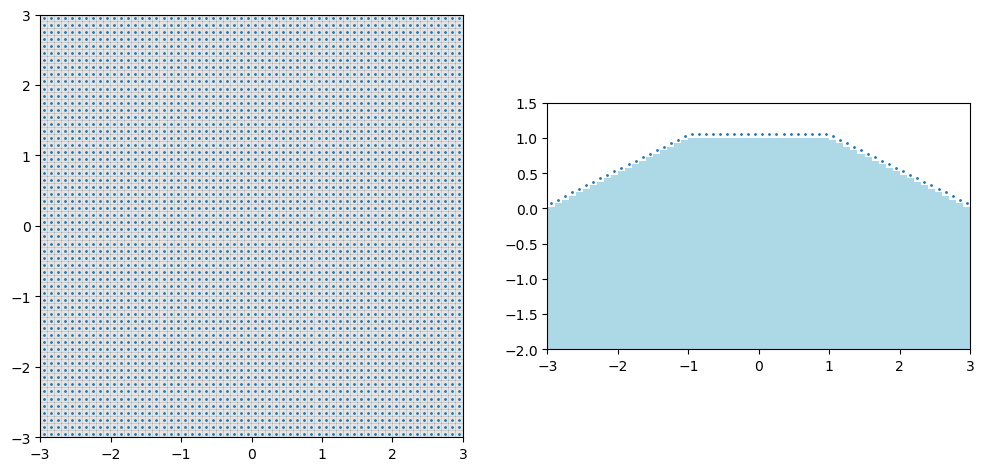

In [7]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs1, yobs1] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs1 = xobs1.reshape(-1)
yobs1 = yobs1.reshape(-1)
zobs1 = np.zeros(len(xobs1))

for i in range(len(xobs1)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs1[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs1[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs1[i] = T.reshape(-1)[j] + 0.05 # 地表から 50 m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs1, yobs1, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs1[(0<yobs1)&(yobs1<incy)], zobs1[(0<yobs1)&(yobs1<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Kernel matrix

In [8]:
%%time
# threadingを用いた並列計算で核行列を求める
# 単位ベクトル作成
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# スレッドの数（並列計算を動かす数）
n = 12

# 全グリッドに関する計算範囲 i = [0, nz] を n 個に分割
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# ThreadPool に各threadの返り値を格納させる
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs1, yobs1, zobs1, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# 計算結果を取り出し、積み上げて最終的な核行列にする
K1 = []
for res in results:
    Ki = res.result()
    if len(K1) == 0:
        K1 = Ki.copy()
    else:
        K1 = np.hstack((K1, Ki))

[ 0  2  5  7 10 13 15 18 21 23 26 30]
18000
0
54000
36000
83000
65000
47000
94000
76000
8000
26000
1000
55000
37000
19000
84000
66000
48000
95000
77000
9000
27000
2000
56000
38000
20000
85000
67000
49000
96000
78000
10000
28000
3000
57000
39000
21000
86000
68000
50000
97000
79000
11000
29000
4000
58000
40000
22000
87000
69000
51000
98000
80000
12000
30000
5000
59000
88000
41000
23000
70000
52000
99000
81000
13000
31000
60000
6000
89000
42000
71000
24000
53000
82000
100000
14000
61000
32000
7000
90000
72000
43000
25000
101000
15000
62000
33000
91000
73000
44000
102000
16000
63000
34000
92000
74000
45000
103000
17000
64000
35000
93000
75000
46000
104000
105000
106000
107000
CPU times: total: 3h 17min 38s
Wall time: 1h 16min 2s


In [10]:
# Depth weighting
w1 = np.linalg.norm(K1, axis=0)
X1 = K1 / w1

CPU times: total: 2.05 s
Wall time: 2.12 s


### Input models

Text(0.5, 1.0, 'fobs4 (nT)')

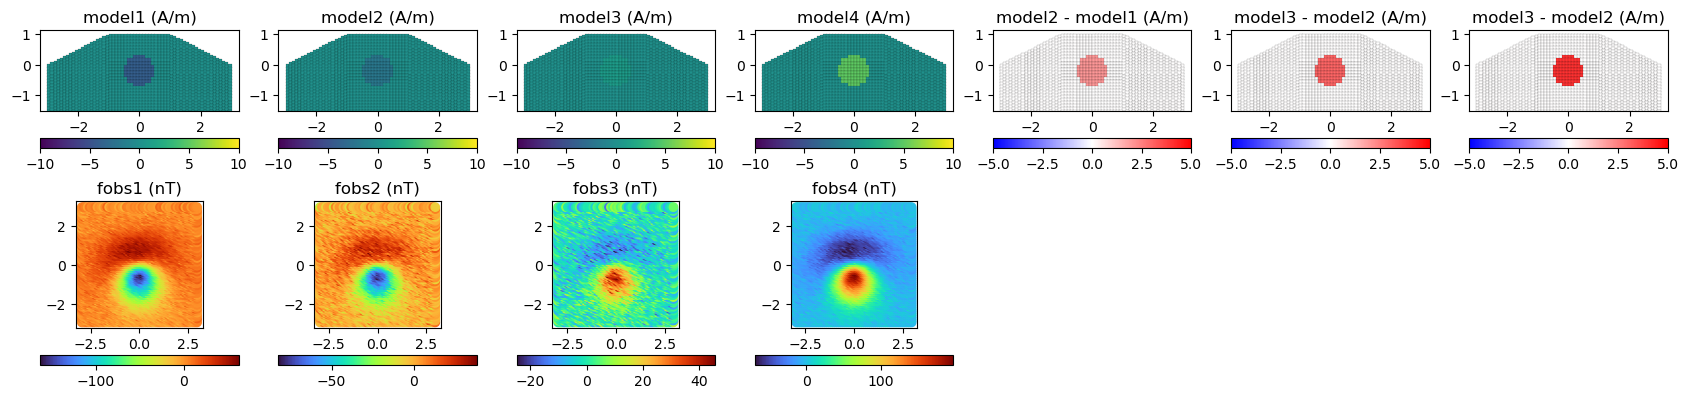

In [11]:
### 磁化構造  ###

# 回転楕円状消磁源  
zcenter = -0.2
a_rad = 0.5 # 半径
b_rad = 0.5
c_rad = 0.5

# ------------------------------------------------------------ #

# Time1
beta1 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta1[k] = -4

# Time2
beta2 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta2[k] = -2

# Time3
beta3 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta3[k] = 1

# Time4
beta4 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta4[k] = 5

# ------------------------------------------------------------ #

# 磁気異常の計算
f1_row = K1.dot(beta1)
f2_row = K1.dot(beta2)
f3_row = K1.dot(beta3)
f4_row = K1.dot(beta4)

# ガウシアンノイズを加える 
np.random.seed(42)
noise1 = np.random.normal(loc=0, scale=5.0, size=len(f1_row)) # 5nT
noise2 = np.random.normal(loc=0, scale=5.0, size=len(f2_row)) # 5nT
noise3 = np.random.normal(loc=0, scale=5.0, size=len(f3_row)) # 5nT
noise4 = np.random.normal(loc=0, scale=5.0, size=len(f4_row)) # 5nT
fobs1 = f1_row + noise1
fobs2 = f2_row + noise2
fobs3 = f3_row + noise3
fobs4 = f4_row + noise4

bb1 = beta1.reshape(nz, ny, nx)
bb2 = beta2.reshape(nz, ny, nx)
bb3 = beta3.reshape(nz, ny, nx)
bb4 = beta4.reshape(nz, ny, nx)


In [ ]:
%%time
# カラーマップ
cmap = cm.get_cmap("gist_earth")
norm = Normalize(vmin = -100, vmax = 1100)

# 図示
fig = plt.figure(figsize = (14, 12.5))
plt.subplots_adjust(wspace=0.1, hspace=-0.3)

#--- Topography ---#

ax = fig.add_subplot(541)
p = ax.pcolor(X, Y, T*1e3, cmap = cmap)
p.set_clim(-100, 1100)

ax.plot([-3.0, 3.0], [0.0, 0.0], linestyle='--', color='white', linewidth=2)

ax.set_aspect("equal")
ax.set_xlim(-3, )
ax.set_ylim(-3, )
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Topography (m)", fontsize = 12)


#--- Input model ---#

# カラーマップ
cmap = cm.get_cmap("RdYlBu")
norm = Normalize(vmin = -6, vmax = 6)

# T = T1
ax = fig.add_subplot(5,4,9)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta1[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T2
ax = fig.add_subplot(5,4,10)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta2[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T3
ax = fig.add_subplot(5,4,11)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta3[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T4
ax = fig.add_subplot(5,4,12)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta4[i]
        color = cmap(norm(beta_val))

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_4$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

### data ###

# T = T_1
ax = fig.add_subplot(5,4,17)
p = ax.scatter(xobs1, yobs1, c = fobs1, cmap = "turbo", s = 1)
p.set_clim(-200, 100)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 100)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_2
ax = fig.add_subplot(5,4,18)
p = ax.scatter(xobs1, yobs1, c = fobs2, cmap = "turbo", s = 1)
p.set_clim(-100, 50)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -100, vmax = 50)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_3
ax = fig.add_subplot(5,4,19)
p = ax.scatter(xobs1, yobs1, c = fobs3, cmap = "turbo", s = 1)
p.set_clim(-30, 50)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -30, vmax = 50)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_4
ax = fig.add_subplot(5,4,20)
p = ax.scatter(xobs1, yobs1, c = fobs4, cmap = "turbo", s = 1)
p.set_clim(-100, 200)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -100, vmax = 200)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

### Parallel Inversion

In [13]:
# hyper-parameters
lams = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams = {}".format(lams))

# ratio of L1 norm and L2 norm
alpha_ = 0.9

lams = [  1.           1.77827941   3.16227766   5.62341325  10.
  17.7827941   31.6227766   56.23413252 100.         177.827941
 316.22776602]


In [14]:
%%time
params_all = []
betas1_all = []
betas2_all = []
betas3_all = []
betas4_all = []

for li in range(len(lams)):

    params_all.append(lams[li])
    
    l_1 = lams[li] * alpha_
    l_2 = lams[li] * (1. - alpha_)
    print("λ1 = {}, λ2 = {}".format(l_1, l_2))
    
    # インバージョン解析を実行
    model1 = L1L2(l_1, l_2, rho_ = 1.0, eta_ = 0., fit_intercept = False, eps_ADMM = 1.e-3)
    model1.algorithm(X1, fobs1, w1)
    beta_sim1 = model1.beta_ / w1
    
    model2 = L1L2(l_1, l_2, rho_ = 1.0, eta_ = 0., fit_intercept = False, eps_ADMM = 1.e-3)
    model2.algorithm(X1, fobs2, w1)
    beta_sim2 = model2.beta_ / w1
    
    model3 = L1L2(l_1, l_2, rho_ = 1.0, eta_ = 0., fit_intercept = False, eps_ADMM = 1.e-3)
    model3.algorithm(X1, fobs3, w1)
    beta_sim3 = model3.beta_ / w1
    
    model4 = L1L2(l_1, l_2, rho_ = 1.0, eta_ = 0., fit_intercept = False, eps_ADMM = 1.e-3)
    model4.algorithm(X1, fobs4, w1)
    beta_sim4 = model4.beta_ / w1

    betas1_all.append(beta_sim1)
    betas2_all.append(beta_sim2)
    betas3_all.append(beta_sim3)
    betas4_all.append(beta_sim4)

# ndarry
params_all = np.array(params_all)
betas1_all = np.array(betas1_all)
betas2_all = np.array(betas2_all)
betas3_all = np.array(betas3_all)
betas4_all = np.array(betas4_all)

λ1 = 0.9, λ2 = 0.09999999999999998
intercept = False
no-constrained
iter = 0, delta = 0.24868531513130593
95
intercept = False
no-constrained
iter = 0, delta = 0.22940722028384067
82
intercept = False
no-constrained
iter = 0, delta = 0.22061613709720057
68
intercept = False
no-constrained
iter = 0, delta = 0.25723163763916296
90
λ1 = 1.6004514690350304, λ2 = 0.17782794100389224
intercept = False
no-constrained
iter = 0, delta = 0.32930939626962413
161
intercept = False
no-constrained
iter = 0, delta = 0.30546806295734513
142
intercept = False
no-constrained
iter = 0, delta = 0.29875224881918216
111
intercept = False
no-constrained
iter = 0, delta = 0.33986781311578307
158
λ1 = 2.8460498941515415, λ2 = 0.3162277660168379
intercept = False
no-constrained
iter = 0, delta = 0.3907648666580252
255
intercept = False
no-constrained
iter = 0, delta = 0.37148798392791216
236
intercept = False
no-constrained
iter = 0, delta = 0.3641328756043776
179
intercept = False
no-constrained
iter = 0, delt

In [15]:
import pickle
with open('Params_case_1_1_parallel.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('Betas1_case_1_1_parallel.pickle', 'wb') as f:
    pickle.dump(betas1_all, f)
with open('Betas2_case_1_1_parallel.pickle', 'wb') as f:
    pickle.dump(betas2_all, f)
with open('Betas3_case_1_1_parallel.pickle', 'wb') as f:
    pickle.dump(betas3_all, f)
with open('Betas4_case_1_1_parallel.pickle', 'wb') as f:
    pickle.dump(betas4_all, f)

In [16]:
# calc rss, pen
# T1
rss_temp_1 = []
pen_temp_1 = []
for i in range(len(lams)):
    rss_temp_1.append(misfit(fobs1, K1, betas1_all[i]))
    pen_temp_1.append(pen(betas1_all[i]*w1, alpha=0.9))

# T2
rss_temp_2 = []
pen_temp_2 = []
for i in range(len(lams)):
    rss_temp_2.append(misfit(fobs2, K1, betas2_all[i]))
    pen_temp_2.append(pen(betas2_all[i]*w1, alpha=0.9))

# T3
rss_temp_3 = []
pen_temp_3 = []
for i in range(len(lams)):
    rss_temp_3.append(misfit(fobs3, K1, betas3_all[i]))
    pen_temp_3.append(pen(betas3_all[i]*w1, alpha=0.9))

# T4
rss_temp_4 = []
pen_temp_4 = []
for i in range(len(lams)):
    rss_temp_4.append(misfit(fobs4, K1, betas4_all[i]))
    pen_temp_4.append(pen(betas4_all[i]*w1, alpha=0.9))

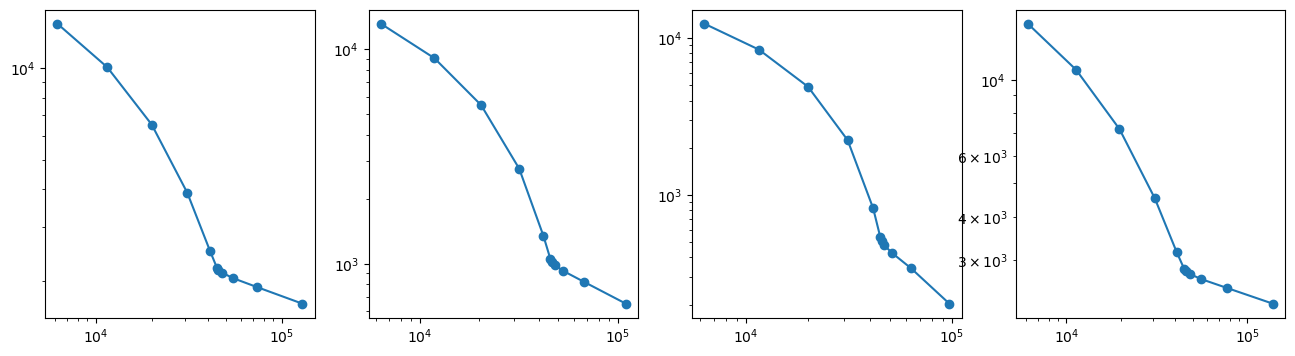

In [17]:
# L-curve
fig = plt.figure(figsize = (16, 4))

ax = fig.add_subplot(141)
ax.loglog(rss_temp_1, pen_temp_1, "o-")

ax = fig.add_subplot(142)
ax.loglog(rss_temp_2, pen_temp_2, "o-")

ax = fig.add_subplot(143)
ax.loglog(rss_temp_3, pen_temp_3, "o-")

ax = fig.add_subplot(144)
ax.loglog(rss_temp_4, pen_temp_4, "o-")

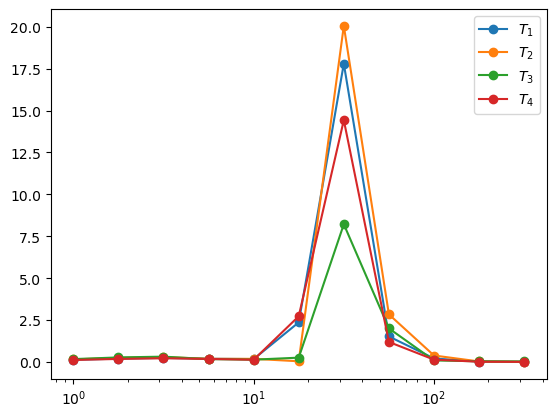

In [18]:
plt.semilogx(lams, calcCurvature2(np.log(rss_temp_1), np.log(pen_temp_1)), "o-", label = "$T_1$")
plt.semilogx(lams, calcCurvature2(np.log(rss_temp_2), np.log(pen_temp_2)), "o-", label = "$T_2$")
plt.semilogx(lams, calcCurvature2(np.log(rss_temp_3), np.log(pen_temp_3)), "o-", label = "$T_3$")
plt.semilogx(lams, calcCurvature2(np.log(rss_temp_4), np.log(pen_temp_4)), "o-", label = "$T_4$")
plt.legend()